In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# remonte les dossiers jusqu'à trouver celui qui contient "src"
RACINE = Path.cwd()
while not (RACINE / "src").exists() and RACINE != RACINE.parent:
    RACINE = RACINE.parent
print("Racine du projet :", RACINE)

sys.path.append(str(RACINE / "src"))
from clean import charger_brut

df = charger_brut(RACINE / "data" / "raw")
propres = pd.read_parquet(RACINE / "data" / "processed" / "ventes_clean.parquet")
print(len(df), "lignes brutes →", len(propres), "ventes propres")

Racine du projet : /Users/jamesrigault/Projets/immo-montpellier
81361 lignes brutes → 23703 ventes propres


In [3]:
colonnes = ["id_mutation", "valeur_fonciere", "type_local", "surface_reelle_bati",
            "nature_culture", "surface_terrain"]
multi = df[df["id_mutation"].duplicated(keep=False)]
exemple = multi["id_mutation"].iloc[0]
df[df["id_mutation"] == exemple][colonnes]

,id_mutation,valeur_fonciere,type_local,surface_reelle_bati,nature_culture,surface_terrain
0,2021-549127,62425.0,Appartement,27.0,NaN,NaN
1,2021-549127,62425.0,Dépendance,NaN,NaN,NaN


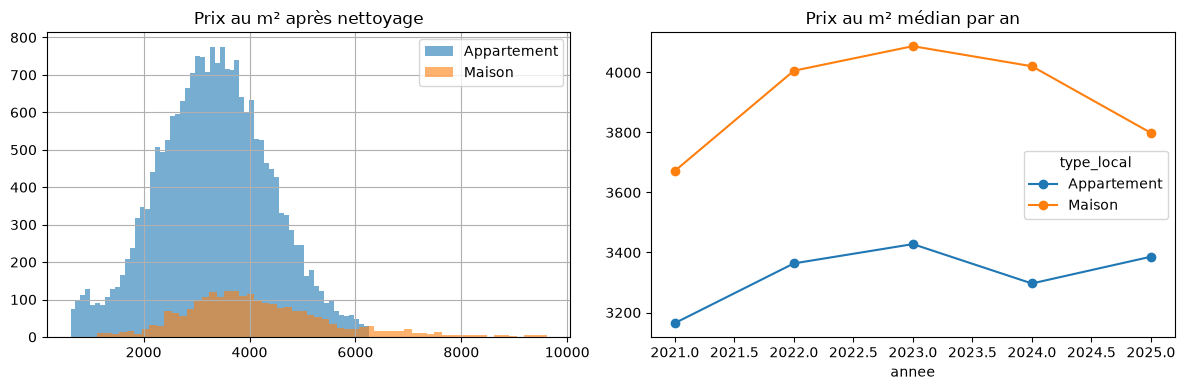

type_local                  Appartement       Maison
prix_m2             count  21313.000000  2390.000000
                    mean    3323.615846  4145.289910
                    std     1054.158199  1411.950247
                    min      619.790123  1111.111111
                    25%     2607.142857  3209.056351
                    50%     3328.125000  3935.910494
                    75%     4037.037037  4863.175402
                    max     6250.000000  9610.389610
surface_reelle_bati count  21313.000000  2390.000000
                    mean      55.293014   102.348954
                    std       26.810482    39.251670
                    min        9.000000    20.000000
                    25%       35.000000    78.000000
                    50%       53.000000    94.000000
                    75%       70.000000   117.000000
                    max      298.000000   368.000000
nb_dependances      count  21313.000000  2390.000000
                    mean       1.070192     0.323431
                    std        0.779181     0.534686
                    min        0.000000     0.000000
                    25%        1.000000     0.000000
                    50%        1.000000     0.000000
                    75%        1.000000     1.000000
                    max        7.000000     4.000000

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for type_local, groupe in propres.groupby("type_local"):
    groupe["prix_m2"].hist(bins=60, alpha=0.6, label=type_local, ax=axes[0])
axes[0].set_title("Prix au m² après nettoyage")
axes[0].legend()

propres["annee"] = propres["date_mutation"].dt.year
propres.groupby(["annee", "type_local"])["prix_m2"].median().unstack().plot(marker="o", ax=axes[1])
axes[1].set_title("Prix au m² médian par an")
plt.tight_layout()
plt.show()

propres.groupby("type_local")[["prix_m2", "surface_reelle_bati", "nb_dependances"]].describe().T